## Load Data
We load Brent, WTI and TTF Natural Gas prices for the Iran 2026 conflict 
window (Feb 21 – present). TTF data is sourced from Investing.com as EIA 
does not track European gas prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load master for Brent and WTI
master = pd.read_csv('../outputs/master_prices.csv', parse_dates=['date'])

# Slice Iran window
iran = master[master['date'] >= '2026-02-21'].copy().reset_index(drop=True)

# Load TTF gas data
ttf = pd.read_csv('../data/Dutch TTF Natural Gas Futures Historical Data.csv')
ttf = ttf[['Date', 'Price']].rename(columns={'Date': 'date', 'Price': 'ttf'})
ttf['date'] = pd.to_datetime(ttf['date'])
ttf = ttf.sort_values('date').reset_index(drop=True)

# Merge TTF into iran window
iran = iran.reset_index(drop=True)
iran = pd.merge(iran[['date', 'brent', 'wti', 'gas', 'name', 'type']], ttf, on='date', how='left')

print(iran)

        date  brent    wti    gas                   name type     ttf
0 2026-02-23  71.90  66.36  3.072                    NaN  NaN  31.834
1 2026-02-24  71.21  65.62  3.072                    NaN  NaN  30.891
2 2026-02-25  70.69  65.30  3.072                    NaN  NaN  31.050
3 2026-02-26  71.66  65.10  3.072                    NaN  NaN  32.224
4 2026-02-27  71.32  66.96  3.072                    NaN  NaN  31.959
5 2026-03-02  77.24  71.13  3.148  US-Israel war on Iran  war  44.506


## Save Iran 2026 Daily Data
Export the Iran conflict price window to CSV. This file will be updated 
regularly as new price data becomes available.

In [2]:
iran.to_csv('../outputs/iran_2026_daily.csv', index=False)
print("Saved! Shape:", iran.shape)

Saved! Shape: (6, 7)


## Build Iran Conflict Timeline
We manually construct a granular timeline of key conflict events to use 
as annotation markers on our charts. This will be updated as the 
situation develops.

In [3]:
iran_events = pd.DataFrame([
    {'date': '2026-02-28', 'event': 'US-Israel strikes begin, Supreme Leader assassinated', 'category': 'military'},
    {'date': '2026-03-01', 'event': 'Tanker transits drop from 24/day to 4', 'category': 'supply'},
    {'date': '2026-03-02', 'event': 'VLCC freight rates hit all-time high of $423k/day', 'category': 'market'},
    {'date': '2026-03-03', 'event': 'QatarEnergy halts LNG production at Ras Laffan', 'category': 'supply'},
    {'date': '2026-03-04', 'event': 'NYT reports Iranian back-channel ceasefire talks', 'category': 'diplomatic'},
    {'date': '2026-03-05', 'event': 'South Korea warns LNG reserves critical (9 days remaining)', 'category': 'supply'},
])

iran_events['date'] = pd.to_datetime(iran_events['date'])
iran_events = iran_events.sort_values('date').reset_index(drop=True)

iran_events.to_csv('../outputs/iran_events.csv', index=False)
print(iran_events)

        date                                              event    category
0 2026-02-28  US-Israel strikes begin, Supreme Leader assass...    military
1 2026-03-01              Tanker transits drop from 24/day to 4      supply
2 2026-03-02  VLCC freight rates hit all-time high of $423k/day      market
3 2026-03-03     QatarEnergy halts LNG production at Ras Laffan      supply
4 2026-03-04   NYT reports Iranian back-channel ceasefire talks  diplomatic
5 2026-03-05  South Korea warns LNG reserves critical (9 day...      supply


## Calibrate Scenario Speeds from Historical Data
Rather than assuming arbitrary speed parameters, we calculate them from 
historical events with similar characteristics to each scenario. This 
grounds our projections in real observed price behaviour.

- **Scenario A (quick resolution):** Calibrated from 9/11 — prices recovered 
  within ~3 days, representing a fast-moving situation
- **Scenario B (prolonged disruption):** Calibrated from Libya 2011 — a slow 
  burning supply disruption that took 74 days to peak
- **Scenario C (escalation):** Calibrated from Ukraine 2022 — a fast geopolitical 
  shock that hit peak price in 12 days

In [4]:
# Load historical metrics
metrics = pd.read_csv('../outputs/event_metrics.csv', parse_dates=['date'])

# Extract days to peak for our calibration events
ukraine_days = metrics.loc[metrics['event'] == 'Ukraine invasion', 'days_to_peak'].values[0]
libya_days   = metrics.loc[metrics['event'] == 'Libya civil war', 'days_to_peak'].values[0]
nine11_days  = metrics.loc[metrics['event'] == '9/11 attacks', 'days_to_peak'].values[0]

# Back-calculate speed: at days_to_peak, curve should be ~95% of the way to target
# 0.95 = 1 - exp(-speed * days_to_peak)
# exp(-speed * days_to_peak) = 0.05
# speed = -ln(0.05) / days_to_peak

speed_c = -np.log(0.05) / ukraine_days
speed_b = -np.log(0.05) / libya_days
speed_a = -np.log(0.05) / nine11_days

print(f"Scenario A speed (9/11):     {speed_a:.4f} — peaks in ~{nine11_days} days")
print(f"Scenario B speed (Libya):    {speed_b:.4f} — peaks in ~{libya_days} days")
print(f"Scenario C speed (Ukraine):  {speed_c:.4f} — peaks in ~{ukraine_days} days")

Scenario A speed (9/11):     0.9986 — peaks in ~3 days
Scenario B speed (Libya):    0.0405 — peaks in ~74 days
Scenario C speed (Ukraine):  0.2496 — peaks in ~12 days


## Scenario Projections
We model three forward-looking price trajectories for Brent crude based 
on analyst forecasts. Each scenario represents a different conflict outcome 
fanning out from today's price (March 2, 2026 — latest available data).

- 🟢 Scenario A: Quick resolution — ceasefire within 2 weeks
- 🟡 Scenario B: Prolonged disruption — 4–8 weeks of Hormuz disruption
- 🔴 Scenario C: Escalation — full closure 2+ months, Saudi infrastructure hit

In [5]:
# Starting point
start_date = pd.Timestamp('2026-03-02')
current_price = 77.24
days = np.arange(0, 91)
dates = [start_date + pd.Timedelta(days=int(d)) for d in days]

# Scenario curves - exponential decay toward target price
def scenario_curve(start, target, days, speed=0.05):
    return start + (target - start) * (1 - np.exp(-speed * days))

scenario_a = scenario_curve(current_price, 68, days, speed=speed_a) # quick resolution
scenario_b = scenario_curve(current_price, 100, days, speed=speed_b) # prolonged
scenario_c = scenario_curve(current_price, 145, days, speed=speed_c) # escalation

projections = pd.DataFrame({
    'date': dates,
    'Scenario A': scenario_a.round(2),
    'Scenario B': scenario_b.round(2),
    'Scenario C': scenario_c.round(2)
})

projections.to_csv('../outputs/scenario_projections.csv', index=False)
print(projections.head(10))

        date  Scenario A  Scenario B  Scenario C
0 2026-03-02       77.24       77.24       77.24
1 2026-03-03       71.40       78.14       92.21
2 2026-03-04       69.25       79.01      103.87
3 2026-03-05       68.46       79.84      112.96
4 2026-03-06       68.17       80.64      120.04
5 2026-03-07       68.06       81.41      125.55
6 2026-03-08       68.02       82.15      129.85
7 2026-03-09       68.01       82.86      133.20
8 2026-03-10       68.00       83.54      135.80
9 2026-03-11       68.00       84.19      137.84


## Scenario Projection Chart
We plot the three forward-looking price trajectories fanning out from 
today's price. The actual price will be plotted against these scenarios 
as new data becomes available.

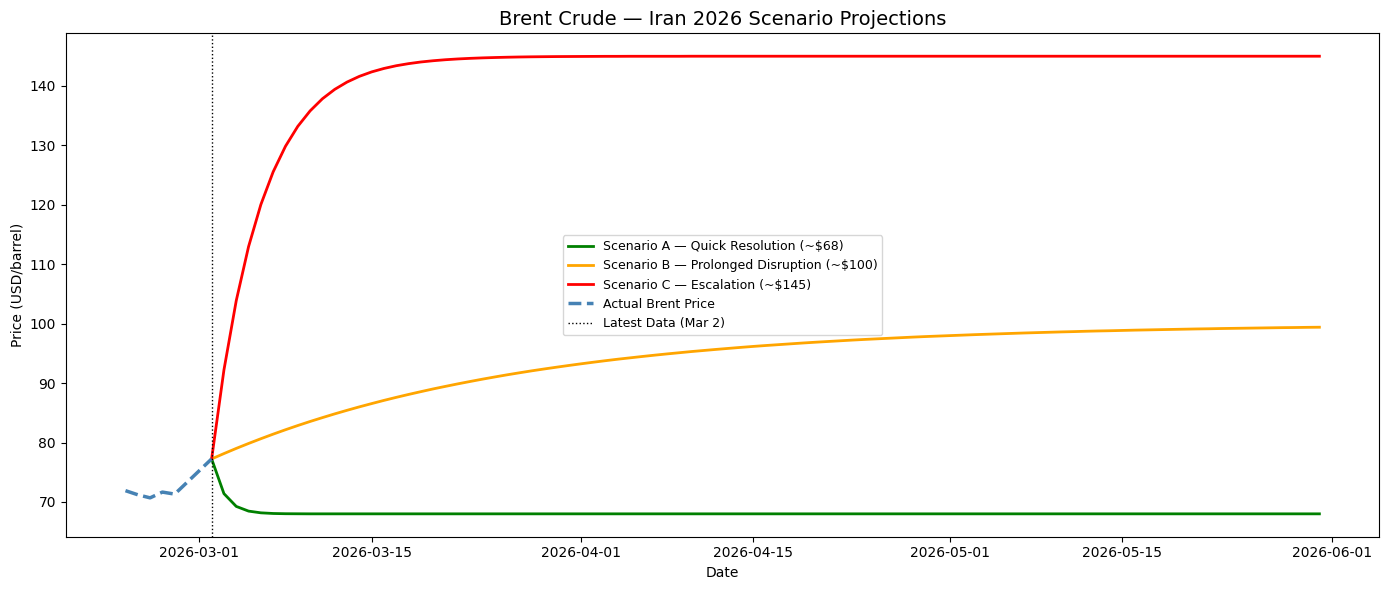

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(projections['date'], projections['Scenario A'], color='green', linewidth=2, label='Scenario A — Quick Resolution (~$68)')
ax.plot(projections['date'], projections['Scenario B'], color='orange', linewidth=2, label='Scenario B — Prolonged Disruption (~$100)')
ax.plot(projections['date'], projections['Scenario C'], color='red', linewidth=2, label='Scenario C — Escalation (~$145)')

# Plot actual price so far
ax.plot(iran['date'], iran['brent'], color='steelblue', linewidth=2.5, linestyle='--', label='Actual Brent Price')

# Mark today
ax.axvline(pd.Timestamp('2026-03-02'), color='black', linestyle=':', linewidth=1, label='Latest Data (Mar 2)')

ax.set_title('Brent Crude — Iran 2026 Scenario Projections', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD/barrel)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/iran_scenario_chart.png', dpi=150)
plt.show()

## Scenario Chart Analysis
The three scenarios are calibrated from historical geopolitical events 
with similar characteristics, rather than assumed speeds.

- **Scenario A (green):** Calibrated from 9/11 — a fast resolution drives 
  prices back to $68 within ~3 days as war risk premium evaporates
- **Scenario B (orange):** Calibrated from Libya 2011 — a slow burning 
  supply disruption that grinds toward $100 over ~74 days
- **Scenario C (red):** Calibrated from Ukraine 2022 — an aggressive 
  escalation spike toward $145 within ~12 days, matching the 2008 all-time high


## Country Vulnerability Analysis
We rank key countries by their exposure to the Strait of Hormuz disruption 
across three dimensions: oil exposure, LNG exposure, and availability of 
pipeline alternatives. This feeds directly into the Tableau world heatmap.

Scoring: High = 3, Medium = 2, Low = 1. Total vulnerability score is the 
sum of oil and LNG exposure minus pipeline alternatives.

In [7]:
vulnerability = pd.DataFrame([
    {'country': 'South Korea', 'oil_exposure': 3, 'lng_exposure': 3, 'pipeline_alternatives': 1, 'notes': 'No pipeline alternatives, 20% of gas from region'},
    {'country': 'Japan',       'oil_exposure': 3, 'lng_exposure': 3, 'pipeline_alternatives': 1, 'notes': 'No pipeline alternatives, heavily LNG dependent'},
    {'country': 'Pakistan',    'oil_exposure': 3, 'lng_exposure': 3, 'pipeline_alternatives': 1, 'notes': 'Highly dependent, no alternatives'},
    {'country': 'Taiwan',      'oil_exposure': 3, 'lng_exposure': 3, 'pipeline_alternatives': 1, 'notes': 'No domestic production, no pipeline alternatives'},
    {'country': 'Singapore',   'oil_exposure': 3, 'lng_exposure': 3, 'pipeline_alternatives': 1, 'notes': 'Entirely import dependent, major refining hub'},
    {'country': 'India',       'oil_exposure': 3, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'Can pivot to Russian supply'},
    {'country': 'China',       'oil_exposure': 3, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'Can pivot to Russian supply'},
    {'country': 'Thailand',    'oil_exposure': 3, 'lng_exposure': 2, 'pipeline_alternatives': 1, 'notes': 'High oil dependency, limited alternatives'},
    {'country': 'Philippines', 'oil_exposure': 3, 'lng_exposure': 2, 'pipeline_alternatives': 1, 'notes': 'Island nation, no pipeline alternatives'},
    {'country': 'Germany',     'oil_exposure': 2, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'Partial pipeline alternatives via Norway'},
    {'country': 'France',      'oil_exposure': 2, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'Nuclear buffered but still oil dependent'},
    {'country': 'Italy',       'oil_exposure': 2, 'lng_exposure': 3, 'pipeline_alternatives': 2, 'notes': 'High LNG dependency, some pipeline alternatives'},
    {'country': 'Spain',       'oil_exposure': 2, 'lng_exposure': 3, 'pipeline_alternatives': 2, 'notes': 'Major LNG importer'},
    {'country': 'United Kingdom', 'oil_exposure': 1, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'North Sea production provides buffer'},
    {'country': 'Turkey',      'oil_exposure': 3, 'lng_exposure': 2, 'pipeline_alternatives': 2, 'notes': 'Strategic location, some pipeline access'},
    {'country': 'Brazil',      'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 2, 'notes': 'Major domestic producer'},
    {'country': 'Australia',   'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 2, 'notes': 'Major LNG exporter, self sufficient'},
    {'country': 'USA',         'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 3, 'notes': 'Buffered by domestic production'},
    {'country': 'Canada',      'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 3, 'notes': 'Major domestic producer'},
    {'country': 'Russia',      'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 3, 'notes': 'Major exporter, not exposed'},
    {'country': 'Saudi Arabia', 'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 3, 'notes': 'Major exporter'},
    {'country': 'Iraq',        'oil_exposure': 1, 'lng_exposure': 1, 'pipeline_alternatives': 3, 'notes': 'Major exporter'},
])

vulnerability['vulnerability_score'] = (
    vulnerability['oil_exposure'] + 
    vulnerability['lng_exposure'] - 
    vulnerability['pipeline_alternatives']
)

vulnerability = vulnerability.sort_values('vulnerability_score', ascending=False).reset_index(drop=True)

vulnerability.to_csv('../outputs/country_vulnerability.csv', index=False)
print(vulnerability[['country', 'oil_exposure', 'lng_exposure', 'pipeline_alternatives', 'vulnerability_score']])

           country  oil_exposure  lng_exposure  pipeline_alternatives  \
0      South Korea             3             3                      1   
1            Japan             3             3                      1   
2         Pakistan             3             3                      1   
3           Taiwan             3             3                      1   
4        Singapore             3             3                      1   
5         Thailand             3             2                      1   
6      Philippines             3             2                      1   
7            India             3             2                      2   
8            China             3             2                      2   
9            Italy             2             3                      2   
10           Spain             2             3                      2   
11          Turkey             3             2                      2   
12          France             2             2     

## Vulnerability Score Analysis
Countries are ranked by a composite vulnerability score (oil exposure + 
LNG exposure - pipeline alternatives). Higher scores indicate greater 
exposure to a prolonged Strait of Hormuz disruption.

**Most vulnerable (score 5):** South Korea, Japan, Pakistan, Taiwan and 
Singapore — all heavily import-dependent with no pipeline alternatives. 
South Korea publicly warned it had only 9 days of LNG reserves remaining.

**High vulnerability (score 4):** Thailand and the Philippines — high oil 
dependency with no pipeline alternatives, though slightly less LNG exposed 
than the score 5 group.

**Moderately vulnerable (score 3):** China, India, Italy, Spain and Turkey — 
meaningful exposure but partially buffered. China and India can pivot to 
Russian overland supply; Italy and Spain are major LNG importers with some 
pipeline access.

**Low vulnerability (score 2):** France and Germany — European pipeline 
networks and in France's case nuclear generation provide meaningful buffers.

**Minimal vulnerability (score 1):** United Kingdom — North Sea domestic 
production cushions the blow.

**Not exposed (score 0):** Brazil and Australia — both have significant 
domestic production and are net energy exporters.

**Negative score (-1):** USA, Canada, Russia, Saudi Arabia and Iraq — all 
major producers or exporters who are largely insulated from or actively 
benefit from a Hormuz disruption.